In [11]:
!pip install -q datasets 

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [14]:
print("Loading AG News Dataset...")

dataset = load_dataset("fancyzhx/ag_news")

train_data = dataset["train"]
test_data  = dataset["test"]

print("Training Samples :", len(train_data))
print("Testing Samples  :", len(test_data))

# Display class distribution
label_names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
from collections import Counter
label_counts = Counter(train_data["label"])
print("\nClass Distribution in Training Set:")
for lbl, cnt in sorted(label_counts.items()):
    print(f"  {label_names[lbl]}: {cnt} samples")

Loading AG News Dataset...
Training Samples : 120000
Testing Samples  : 7600

Class Distribution in Training Set:
  World: 30000 samples
  Sports: 30000 samples
  Business: 30000 samples
  Sci/Tech: 30000 samples


In [15]:
print("Building Vocabulary...")

vocab = {
    "<unk>": 0,
    "<pad>": 1
}

def tokenize(text):
    return text.lower().split()

for article in train_data["text"]:
    words = tokenize(article)

    for word in words:
        if word not in vocab:
            vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab))

PAD_IDX = vocab["<pad>"]

Building Vocabulary...
Vocabulary Size: 158735


In [16]:
def numericalize(text):
    words = tokenize(text)

    return [
        vocab.get(word, vocab["<unk>"])
        for word in words
    ]

In [17]:
def collate_batch(batch):

    text_list = []
    label_list = []
    length_list = []

    for item in batch:

        text_tensor = torch.tensor(
            numericalize(item["text"]),
            dtype=torch.long
        )

        text_list.append(text_tensor)
        label_list.append(item["label"])
        length_list.append(len(text_tensor))

    padded_texts = pad_sequence(
        text_list,
        batch_first=True,
        padding_value=PAD_IDX
    )

    return (
        padded_texts.to(device),
        torch.tensor(label_list).to(device),
        torch.tensor(length_list)
    )

In [18]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch
)

test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch
)

In [19]:
class NewsRNNModel(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            100,
            padding_idx=PAD_IDX
        )

        self.rnn = nn.RNN(
            input_size=100,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(128, 4)

    def forward(self, text, lengths):

        embedded = self.embedding(text)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.rnn(packed)

        hidden = hidden.squeeze(0)

        return self.fc(hidden)


In [20]:
model = NewsRNNModel(vocab_size=len(vocab)).to(device)

print("Model Architecture:")
print(model)
print(f"\nTotal Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model Architecture:
NewsRNNModel(
  (embedding): Embedding(158735, 100, padding_idx=1)
  (rnn): RNN(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

Total Trainable Parameters: 15,903,456


In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [22]:
def train():

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for texts, labels, lengths in train_loader:

        optimizer.zero_grad()

        outputs = model(texts, lengths)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

    accuracy = 100 * correct / total

    return total_loss, accuracy

In [23]:
def evaluate():

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for texts, labels, lengths in test_loader:

            outputs = model(texts, lengths)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    accuracy = 100 * correct / total

    return accuracy

In [24]:
EPOCHS = 5

train_loss_history = []
train_acc_history  = []
test_acc_history   = []

print("\nStarting Training...\n")

for epoch in range(EPOCHS):

    train_loss, train_acc = train()
    test_acc = evaluate()

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Test Acc: {test_acc:.2f}%"
    )



Starting Training...

Epoch [1/5] Loss: 1751.4855 Train Acc: 58.94% Test Acc: 68.43%
Epoch [2/5] Loss: 1519.8126 Train Acc: 66.65% Test Acc: 72.89%
Epoch [3/5] Loss: 964.0255 Train Acc: 81.37% Test Acc: 45.92%
Epoch [4/5] Loss: 1265.8361 Train Acc: 72.46% Test Acc: 74.17%
Epoch [5/5] Loss: 966.2829 Train Acc: 80.10% Test Acc: 82.46%


In [25]:
torch.save(
    model.state_dict(),
    "news_classifier_rnn.pth"
)

print("\nModel saved as news_classifier_rnn.pth")


Model saved as news_classifier_rnn.pth


In [26]:
categories = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

def predict_news(text):

    model.eval()

    tokens = torch.tensor(
        [numericalize(text)],
        dtype=torch.long
    ).to(device)

    lengths = torch.tensor(
        [tokens.size(1)]
    )

    with torch.no_grad():

        output = model(tokens, lengths)

        prediction = output.argmax(dim=1).item()

    return categories[prediction]

In [27]:
sample_news = """
The central bank raised interest rates by 50 basis points
to combat rising inflation across global markets.
"""

predicted_label = predict_news(sample_news)

print("\nInput News Headline:")
print(sample_news)
print("Predicted Category:", predicted_label)



Input News Headline:

The central bank raised interest rates by 50 basis points
to combat rising inflation across global markets.

Predicted Category: Business


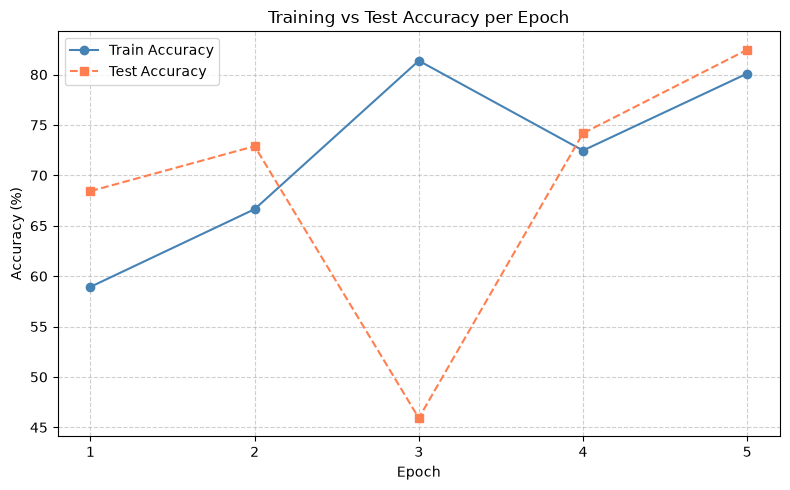

In [28]:
# Training vs Test Accuracy over Epochs
epochs_range = list(range(1, EPOCHS + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_acc_history, marker='o', label='Train Accuracy', color='steelblue')
plt.plot(epochs_range, test_acc_history,  marker='s', label='Test Accuracy',  color='coral', linestyle='--')
plt.title('Training vs Test Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


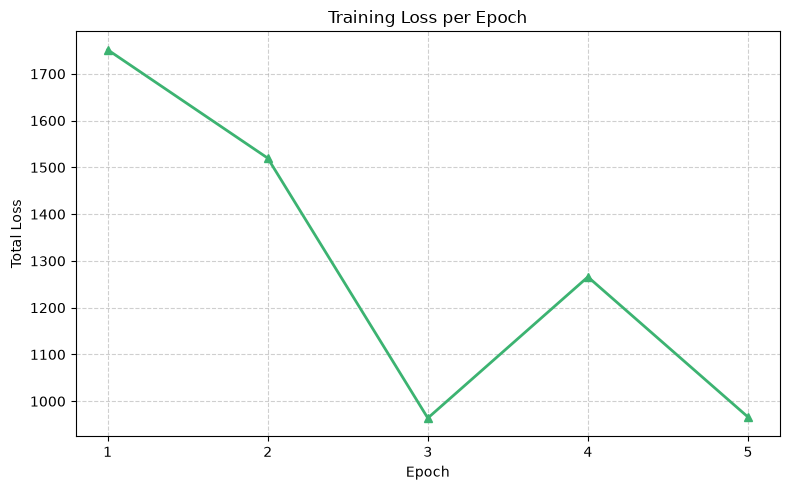

In [29]:
# Training Loss over Epochs
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_loss_history, marker='^', color='mediumseagreen', linewidth=2)
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
